# Manufacturing Value Added and Water Scarcity

In [52]:
import numpy as np
import pandas as pd
import os
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import statsmodels.formula.api as smf

# Data Cleaning

In [53]:
cd = '/Users/amh/Desktop/CEU-EDP/DA4/Project/'

In [54]:
aquastat= pd.read_csv(cd + 'Data/AQUASTAT Dissemination System(1).csv')

In [55]:
manufacturing_df = pd.read_csv(cd +'Data/manufacturing-value-added-to-gdp.csv')
manufacturing_df['Entity'].nunique()

216

In [56]:
z_water = pd.read_csv(cd + 'Data/confounders_water.csv')

## Outcome Variable (Y) Water Stress i.e., Pressure on Water Resources

In [57]:
aquastat.head()

,VariableGroup,Subgroup,Variable,Area,Year,Value,Unit,Symbol,IsAggregate
0,Water use,Pressure on water resources,Agricultural water withdrawal as % of total re...,Afghanistan,1990,37.126198,%,I,False
1,Water use,Pressure on water resources,Agricultural water withdrawal as % of total re...,Afghanistan,1991,36.312150,%,I,False
2,Water use,Pressure on water resources,Agricultural water withdrawal as % of total re...,Afghanistan,1992,35.498101,%,I,False
3,Water use,Pressure on water resources,Agricultural water withdrawal as % of total re...,Afghanistan,1993,34.684052,%,I,False
4,Water use,Pressure on water resources,Agricultural water withdrawal as % of total re...,Afghanistan,1994,33.870003,%,I,False


In [58]:
#Filtering Water Stress (Variable of interest)
water_stress = aquastat[aquastat['Variable'] == 'SDG 6.4.2. Water Stress'].copy()

In [59]:
# Now safely modify the DataFrame
drop_water_stress = ['Symbol', 'IsAggregate', 'VariableGroup', 'Subgroup', 'Variable', 'Unit']
water_stress.drop(columns=drop_water_stress, inplace=True)
water_stress.rename(columns={'Area': 'Country', 'Value': 'val_water_stress'}, inplace=True)

# Check the first few rows to verify changes
water_stress.head()

,Country,Year,val_water_stress
27124,Afghanistan,1990,66.202337
27125,Afghanistan,1991,64.769097
27126,Afghanistan,1992,63.337788
27127,Afghanistan,1993,61.906480
27128,Afghanistan,1994,60.475171


## Explanatory Variable (X): Manufaturing Value Added (% of GDP)

In [60]:
manufacturing_df_cols = {'Entity': 'Country', 'Manufacturing, value added (% of GDP)': 'mva_val'}
manufacturing_df.rename(columns=manufacturing_df_cols, inplace=True)


In [61]:
manufacturing_df.columns

Index(['Country', 'Code', 'Year', 'mva_val'], dtype='object')

In [62]:
manufacturing_df

,Country,Code,Year,mva_val
0,Afghanistan,AFG,2002,18.822752
1,Afghanistan,AFG,2003,16.923866
2,Afghanistan,AFG,2004,17.554007
3,Afghanistan,AFG,2005,16.598211
4,Afghanistan,AFG,2006,16.385538
...,...,...,...,...
8302,Zimbabwe,ZWE,2019,14.222360
8303,Zimbabwe,ZWE,2020,15.696567
8304,Zimbabwe,ZWE,2021,12.442934
8305,Zimbabwe,ZWE,2022,20.533466


In [63]:
manufacturing_df.describe()

,Year,mva_val
count,8307.000000,8307.000000
mean,1999.840616,12.858298
std,16.035533,7.248849
min,1960.000000,0.000000
25%,1989.000000,7.602487
50%,2003.000000,12.446115
75%,2013.000000,17.162633
max,2023.000000,48.442880


### Merged df no zs

In [64]:
y_x = pd.merge(water_stress, manufacturing_df, on=['Country', 'Year'], how='inner')

## Confounders:

### Water Withdrawals

In [65]:
z_water['Series Name'].unique()

array(['Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)',
       'Annual freshwater withdrawals, domestic (% of total freshwater withdrawal)',
       'Annual freshwater withdrawals, industry (% of total freshwater withdrawal)',
       'People using at least basic drinking water services (% of population)',
       'Mortality rate attributed to unsafe water, unsafe sanitation and lack of hygiene (per 100,000 population)',
       'People using safely managed drinking water services (% of population)',
       'People with basic handwashing facilities including soap and water (% of population)',
       nan], dtype=object)

In [66]:
z_water_long = z_water.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    var_name='Year',
    value_name='Value'
).reset_index()
# Remove ' [YRYYYY]' from the 'Year' column
z_water_long['Year'] = z_water_long['Year'].str.extract('(\d{4})')

z_water_long.head()

,index,Country Name,Country Code,Series Name,Series Code,Year,Value
0,0,Afghanistan,AFG,"Annual freshwater withdrawals, agriculture (% ...",ER.H2O.FWAG.ZS,1999,98.614279727
1,1,Afghanistan,AFG,"Annual freshwater withdrawals, domestic (% of ...",ER.H2O.FWDM.ZS,1999,0.8008617371
2,2,Afghanistan,AFG,"Annual freshwater withdrawals, industry (% of ...",ER.H2O.FWIN.ZS,1999,0.5848585359
3,3,Afghanistan,AFG,People using at least basic drinking water ser...,SH.H2O.BASW.ZS,1999,..
4,4,Afghanistan,AFG,"Mortality rate attributed to unsafe water, uns...",SH.STA.WASH.P5,1999,..


In [67]:
z_water_vars = z_water_long.pivot_table(
    index= ['Country Name', 'Country Code', 'Year'],
    columns='Series Name',
    values='Value',
    aggfunc='first'
).reset_index()

In [68]:
z_water_vars.columns

Index(['Country Name', 'Country Code', 'Year',
       'Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)',
       'Annual freshwater withdrawals, domestic (% of total freshwater withdrawal)',
       'Annual freshwater withdrawals, industry (% of total freshwater withdrawal)',
       'Mortality rate attributed to unsafe water, unsafe sanitation and lack of hygiene (per 100,000 population)',
       'People using at least basic drinking water services (% of population)',
       'People using safely managed drinking water services (% of population)',
       'People with basic handwashing facilities including soap and water (% of population)'],
      dtype='object', name='Series Name')

In [69]:
z_water_vars.rename(columns={'Country Name': 'Country', 'Country Code': 'Code'}, inplace=True)
z_water_vars.drop(columns=['Mortality rate attributed to unsafe water, unsafe sanitation and lack of hygiene (per 100,000 population)', 'Country'], inplace=True)
z_water_vars.head()

Series Name,Code,Year,"Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)","Annual freshwater withdrawals, domestic (% of total freshwater withdrawal)","Annual freshwater withdrawals, industry (% of total freshwater withdrawal)",People using at least basic drinking water services (% of population),People using safely managed drinking water services (% of population),People with basic handwashing facilities including soap and water (% of population)
0,AFG,1999,98.614279727,0.8008617371,0.5848585359,..,..,..
1,AFG,2000,98.606201344,0.7602538124,0.6335448436,27.4418560941262,11.0933263091436,..
2,AFG,2001,98.5185761701,0.8080493617,0.6733744681,27.4735802318339,11.1052211474061,..
3,AFG,2002,98.431106592,0.8557600407,0.7131333673,29.6748627315109,12.0077331734354,..
4,AFG,2003,98.3437921956,0.9033860751,0.7528217293,31.8755891610669,12.9099215252666,..


In [70]:
# Merge the dataframes
df = pd.merge(water_stress, manufacturing_df, on=['Country', 'Year'], how='inner')

In [71]:
# Ensure 'Country' and 'Year' columns are of the same type in both DataFrames
df['Code'] = df['Code'].astype(str)
df['Year'] = df['Year'].astype(int)

z_water_vars['Code'] = z_water_vars['Code'].astype(str)
z_water_vars['Year'] = z_water_vars['Year'].astype(int)

# Merge
df_zs = pd.merge(df, z_water_vars, on=['Code', 'Year'], how='inner')

In [72]:
print('df cols', df.columns)
print('z_water_vars cols', z_water_vars.columns)


df cols Index(['Country', 'Year', 'val_water_stress', 'Code', 'mva_val'], dtype='object')
z_water_vars cols Index(['Code', 'Year',
       'Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)',
       'Annual freshwater withdrawals, domestic (% of total freshwater withdrawal)',
       'Annual freshwater withdrawals, industry (% of total freshwater withdrawal)',
       'People using at least basic drinking water services (% of population)',
       'People using safely managed drinking water services (% of population)',
       'People with basic handwashing facilities including soap and water (% of population)'],
      dtype='object', name='Series Name')


### gdp

In [73]:
gdpy = pd.read_csv(cd + 'Data/gdpydf_cleaned.csv')
gdpy.rename(columns= {'GDP_PPP': 'gdpy_val'}, inplace=True)
gdpy


,Country,Code,Year,gdpy_val
0,Africa Eastern and Southern,AFE,1992,3135.101069
1,Africa Eastern and Southern,AFE,1993,3023.988843
2,Africa Eastern and Southern,AFE,1994,2993.630132
3,Africa Eastern and Southern,AFE,1995,3048.085253
4,Africa Eastern and Southern,AFE,1996,3133.177681
...,...,...,...,...
7515,Zimbabwe,ZWE,2019,3294.806084
7516,Zimbabwe,ZWE,2020,2987.269823
7517,Zimbabwe,ZWE,2021,3184.785451
7518,Zimbabwe,ZWE,2022,3323.121932


### Natural Disasters
Filtering water stressing disasters: Floods, Droughts, Storms, and Extreme Temperature

In [74]:
dis_df = pd.read_excel(cd + 'Data/disaster_risk_em-dat_louvan.xlsx')

In [75]:
dis_df['Disaster Type'].unique()

array(['Storm', 'Flood', 'Volcanic activity', 'Earthquake', 'Drought',
       'Mass movement (dry)', 'Mass movement (wet)', 'Wildfire',
       'Extreme temperature', 'Fog', 'Glacial lake outburst flood'],
      dtype=object)

In [76]:
keep_dis = ['Flood', 'Drought', 'Storm', 'Extreme temperature']
vars_dis = ['Disaster Type', 'Start Year', 'ISO', 'Country']

dis_z_df = dis_df[
    dis_df['Disaster Type'].isin(keep_dis) & 
    (dis_df['Start Year'] >= 2000)][vars_dis]

In [77]:
dis_z_df = dis_z_df.sort_values(by=['Country', 'Start Year', 'Disaster Type'])

In [78]:
dis_z_df.head()

,Disaster Type,Start Year,ISO,Country
6731,Drought,2000,AFG,Afghanistan
6766,Extreme temperature,2001,AFG,Afghanistan
7033,Extreme temperature,2001,AFG,Afghanistan
7194,Flood,2002,AFG,Afghanistan
7200,Flood,2002,AFG,Afghanistan


In [79]:
disaster_count = dis_z_df.groupby(['Start Year', 'ISO']).size().reset_index(name='Disaster_Count')
disaster_count.sort_values(by=['ISO', 'Start Year'], inplace=True)
disaster_count.rename(columns={'Start Year': 'Year', 'ISO': 'Code'}, inplace=True)


## saving dfs

In [80]:
# Define base path and output folder
cleaned_data_path = os.path.join(cd,'Cleaned_Data')
dfs = {
    "z_water_vars_cleaned.csv": z_water_vars,
    "manufacturing_df_cleaned.csv": manufacturing_df,
    "water_stress_cleaned.csv": water_stress,
    'disaster_count.csv': disaster_count,
    'gdpy_cleaned.csv': gdpy,
}
# save the cleaned data
for file_name, df in dfs.items():
    df.to_csv(os.path.join(cleaned_data_path, file_name), index=False)
print(f"Data saved successfully to {cleaned_data_path}" )

Data saved successfully to /Users/amh/Desktop/CEU-EDP/DA4/Project/Cleaned_Data


## Merge DF

In [81]:
### Merge the dataframes
# First merge df_zs and gdpy
merged_df = pd.merge(df_zs, gdpy, on=['Code', 'Year'], how='inner')

# Merge with how='left' to keep all years from merged_df
df_all_zs = pd.merge(merged_df, disaster_count, on=['Code', 'Year'], how='left')

# Fill missing values in 'Disaster_Count' with 0
df_all_zs['Disaster_Count'].fillna(0, inplace=True)
df_all_zs


,Country_x,Year,val_water_stress,Code,mva_val,"Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)","Annual freshwater withdrawals, domestic (% of total freshwater withdrawal)","Annual freshwater withdrawals, industry (% of total freshwater withdrawal)",People using at least basic drinking water services (% of population),People using safely managed drinking water services (% of population),People with basic handwashing facilities including soap and water (% of population),Country_y,gdpy_val,Disaster_Count
0,Albania,1999,10.228486,ALB,4.532523,57.6961492814,29.691778005,12.6120727136,..,..,..,Albania,6042.769898,0.0
1,Albania,2000,11.044471,ALB,4.317846,57.6776580694,29.9488518881,12.3734900424,86.3970439494077,49.1383205634209,..,Albania,6503.834597,0.0
2,Albania,2001,10.519591,ALB,4.099040,55.3911543251,31.567702204,13.0411434709,86.9040684917649,49.0811977467469,..,Albania,7109.627581,0.0
3,Albania,2002,9.994712,ALB,4.066543,52.8644956467,33.3565828082,13.778921545,87.4516357159612,48.984765568043,..,Albania,7454.478313,2.0
4,Albania,2003,9.469832,ALB,4.124160,50.0577491782,35.3437662618,14.59848456,87.9871967181199,48.8854457544253,..,Albania,7896.097378,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3046,Zimbabwe,2017,31.346226,ZWE,14.026908,82.9564852805,14.6057320835,2.437782636,63.9966273097218,26.9445884339127,42.4251313333788,Zimbabwe,3453.509708,2.0
3047,Zimbabwe,2018,35.405385,ZWE,13.678137,80.6354257516,17.207486806,2.1570874424,63.5387733496876,26.807938485019,42.4196422521729,Zimbabwe,3572.983589,0.0
3048,Zimbabwe,2019,39.769662,ZWE,14.222360,84.8266315932,13.2529972298,1.920371177,63.0949538019092,26.6839776541278,42.419838127544,Zimbabwe,3294.806084,2.0
3049,Zimbabwe,2020,46.091620,ZWE,15.696567,87.2001825488,11.1428457132,1.656971738,62.6664561104324,26.5738460316127,42.4261100052962,Zimbabwe,2987.269823,0.0


In [82]:
df_all_zs.rename(columns={'Country_x': 'Country'}, inplace=True)
df_all_zs.drop(columns=['Country_y', 'People with basic handwashing facilities including soap and water (% of population)'], inplace=True)
df_all_zs

,Country,Year,val_water_stress,Code,mva_val,"Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)","Annual freshwater withdrawals, domestic (% of total freshwater withdrawal)","Annual freshwater withdrawals, industry (% of total freshwater withdrawal)",People using at least basic drinking water services (% of population),People using safely managed drinking water services (% of population),gdpy_val,Disaster_Count
0,Albania,1999,10.228486,ALB,4.532523,57.6961492814,29.691778005,12.6120727136,..,..,6042.769898,0.0
1,Albania,2000,11.044471,ALB,4.317846,57.6776580694,29.9488518881,12.3734900424,86.3970439494077,49.1383205634209,6503.834597,0.0
2,Albania,2001,10.519591,ALB,4.099040,55.3911543251,31.567702204,13.0411434709,86.9040684917649,49.0811977467469,7109.627581,0.0
3,Albania,2002,9.994712,ALB,4.066543,52.8644956467,33.3565828082,13.778921545,87.4516357159612,48.984765568043,7454.478313,2.0
4,Albania,2003,9.469832,ALB,4.124160,50.0577491782,35.3437662618,14.59848456,87.9871967181199,48.8854457544253,7896.097378,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3046,Zimbabwe,2017,31.346226,ZWE,14.026908,82.9564852805,14.6057320835,2.437782636,63.9966273097218,26.9445884339127,3453.509708,2.0
3047,Zimbabwe,2018,35.405385,ZWE,13.678137,80.6354257516,17.207486806,2.1570874424,63.5387733496876,26.807938485019,3572.983589,0.0
3048,Zimbabwe,2019,39.769662,ZWE,14.222360,84.8266315932,13.2529972298,1.920371177,63.0949538019092,26.6839776541278,3294.806084,2.0
3049,Zimbabwe,2020,46.091620,ZWE,15.696567,87.2001825488,11.1428457132,1.656971738,62.6664561104324,26.5738460316127,2987.269823,0.0


In [126]:
# Define a dictionary with shorter variable names for the specified columns
short_var_names = {
    'Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)': 'water_withdraw_agri',
    'Annual freshwater withdrawals, domestic (% of total freshwater withdrawal)': 'water_withdraw_domestic',
    'Annual freshwater withdrawals, industry (% of total freshwater withdrawal)': 'water_withdraw_industry',
    'People using at least basic drinking water services (% of population)': 'basic_water_services',
    'People using safely managed drinking water services (% of population)': 'safe_water_services'
}

# apply rename to the DataFrame
df_all_zs.rename(columns=short_var_names, inplace=True)

df_all_zs.drop(columns=['water_withdraw_agri', 'water_withdraw_agri', 'water_withdraw_industry', 'safe_water_services'], inplace=True)


In [84]:
df = df_all_zs.copy()
df = df.replace('..', pd.NA)


In [85]:
# Check for missing values
df.isnull().sum()

Country                       0
Year                          0
val_water_stress              0
Code                          0
mva_val                       0
water_withdraw_agri          41
water_withdraw_domestic      68
water_withdraw_industry      81
basic_water_services        174
safe_water_services        1047
gdpy_val                      0
Disaster_Count                0
dtype: int64

In [86]:
# drop columns with more than 30% missing values
df.drop(columns=['safe_water_services'], inplace=True)

# Fill missing values using forward and backward filling within each country for sectoral water withdrawals and basic water services
df = df.sort_values(['Country', 'Year'])
df['water_withdraw_agri'] = df.groupby('Country')['water_withdraw_agri'].ffill().bfill()
df['water_withdraw_domestic'] = df.groupby('Country')['water_withdraw_domestic'].ffill().bfill()
df['water_withdraw_industry'] = df.groupby('Country')['water_withdraw_industry'].ffill().bfill()
df['basic_water_services'] = df.groupby('Country')['basic_water_services'].ffill().bfill()

# Check for missing values after imputation

missing_values_after_imputation = df.isnull().sum()
missing_values_after_imputation

Country                    0
Year                       0
val_water_stress           0
Code                       0
mva_val                    0
water_withdraw_agri        0
water_withdraw_domestic    0
water_withdraw_industry    0
basic_water_services       0
gdpy_val                   0
Disaster_Count             0
dtype: int64

### handling extreme values (Winsorising vs Box Cox)


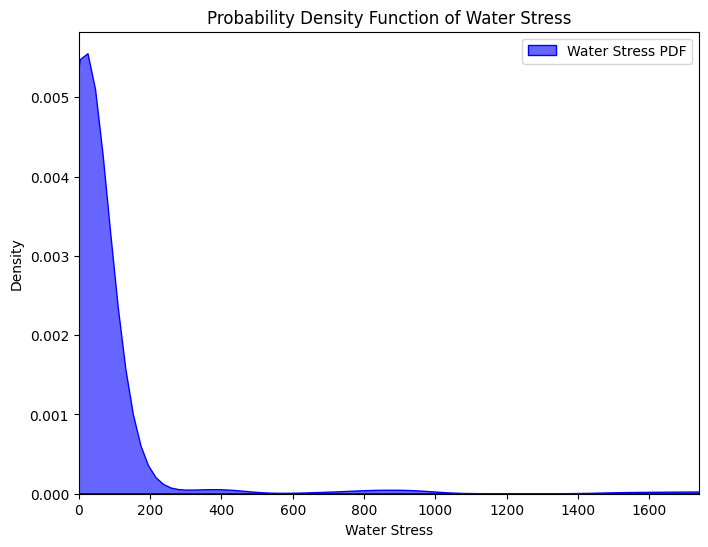

In [87]:
# Drop missing values if any
data = df['val_water_stress'].dropna()

plt.figure(figsize=(8, 6))

# Plot the PDF for val_water_stress only
sns.kdeplot(data, fill=True, alpha=0.6, color='blue', label='Water Stress PDF')

# Limit the x-axis to focus on the majority of data
plt.xlim(0, np.percentile(data, 99))  # Display up to the 99th percentile

plt.title('Probability Density Function of Water Stress')
plt.xlabel('Water Stress')
plt.ylabel('Density')
plt.legend()
plt.show()




In [88]:
# Calculate decile values
deciles_half = df['val_water_stress'].quantile([0.05 * i for i in range(21)])
print(deciles_half)


0.00       0.026730
0.05       0.495794
0.10       1.260294
0.15       1.835400
0.20       2.565905
0.25       3.445392
0.30       4.282896
0.35       5.723339
0.40       6.759667
0.45       8.311833
0.50       9.786096
0.55      12.520109
0.60      16.996942
0.65      22.018051
0.70      28.890430
0.75      37.926877
0.80      50.038956
0.85      66.492093
0.90      90.785414
0.95     137.920360
1.00    3850.500000
Name: val_water_stress, dtype: float64


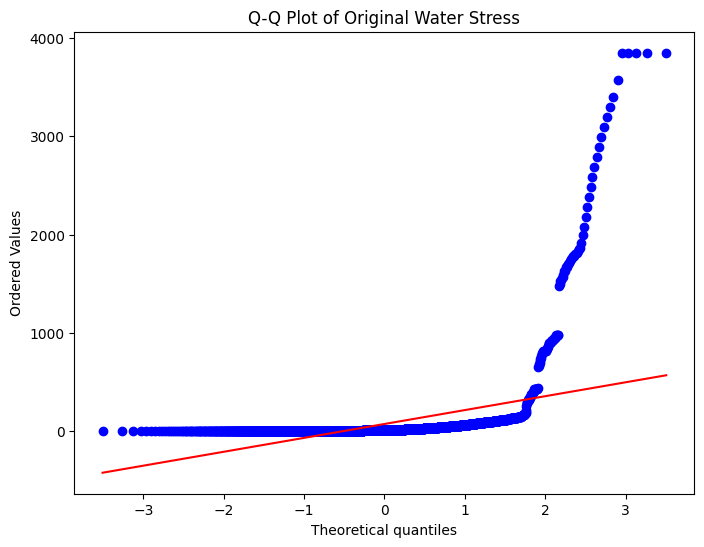

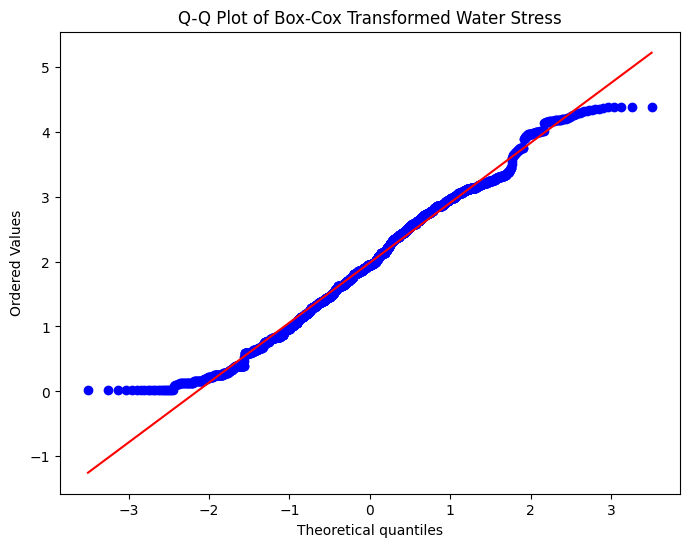

Original Skewness: 8.096853552120237
Box-Cox Skewness: 0.044128806280234516
Original Kurtosis: 75.29826396155075
Box-Cox Kurtosis: -0.5237310469748095


In [89]:
# Q-Q Plot for Original Data
plt.figure(figsize=(8, 6))
stats.probplot(df['val_water_stress'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Original Water Stress')
plt.show()

# Q-Q Plot for Box-Cox Transformed Data
df['val_water_stress_boxcox'], lambda_val = stats.boxcox(df['val_water_stress'] + 1)
plt.figure(figsize=(8, 6))
stats.probplot(df['val_water_stress_boxcox'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Box-Cox Transformed Water Stress')
plt.show()

# Compare Skewness and Kurtosis
print("Original Skewness:", df['val_water_stress'].skew())
print("Box-Cox Skewness:", df['val_water_stress_boxcox'].skew())

print("Original Kurtosis:", df['val_water_stress'].kurtosis())
print("Box-Cox Kurtosis:", df['val_water_stress_boxcox'].kurtosis())


In [90]:
df['val_water_stress_boxcox'], lambda_val = stats.boxcox(df['val_water_stress'] + 1)
print(f"Optimal Lambda for Box-Cox Transformation: {lambda_val}")

Optimal Lambda for Box-Cox Transformation: -0.1740237583267852


## BOX COX TRANSFORMATION: 
When λ < 0, the Box-Cox transformation takes the form of an inverse or reciprocal transformation. The transformation compresses high values and expands low values, helping to reduce right skewness in the water stress variable.
- lambda_val = -0.174  # optimal Box-Cox lambda 
- This lambda value will be used to back-transform from the Box-Cox scale to the original scale 

In [91]:
df_all_zs.to_csv(cd + 'Cleaned_Data/df_all_zs.csv', index=False)

# Models

In [92]:
print(df.describe())

              Year  val_water_stress      mva_val       gdpy_val  \
count  3051.000000       3051.000000  3051.000000    3051.000000   
mean   2010.503769         72.773305    12.978551   23092.224712   
std       6.518340        309.335178     6.865224   23743.756121   
min    1999.000000          0.026730     0.232608     711.976394   
25%    2005.000000          3.445392     8.148509    5740.518356   
50%    2011.000000          9.786096    12.476517   14488.209434   
75%    2016.000000         37.926877    16.839964   34140.366908   
max    2021.000000       3850.500000    48.442880  145591.019357   

       Disaster_Count  val_water_stress_boxcox  
count     3051.000000              3051.000000  
mean         1.499836                 1.981926  
std          2.792540                 0.926087  
min          0.000000                 0.026319  
25%          0.000000                 1.313933  
50%          1.000000                 1.947523  
75%          2.000000                 2.7079

## Finding the best model

In [93]:
did_formula = "val_water_stress ~ Treatment + Post + Treatment_Post"

In [94]:
# Assuming df is your original DataFrame
df_did = df.copy()

# Convert 'Year' to numeric, handle errors if any
df_did['Year'] = pd.to_numeric(df_did['Year'], errors='coerce')

# Create the treatment variable based on MVA being above the median
df_did['Treatment'] = (df_did['mva_val'] > df_did['mva_val'].median()).astype(int)

# Define the post-treatment period as 2015 onwards
df_did['Post'] = (df_did['Year'] > 2015).astype(int)

# Create the interaction term for DiD
df_did['Treatment_Post'] = df_did['Treatment'] * df_did['Post']

# Fit the DiD model with robust standard errors
did_model_15 = smf.ols(formula=did_formula, data=df_did).fit(cov_type='HC3')

# Output the model summary
print(did_model_15.summary())

                            OLS Regression Results                            
Dep. Variable:       val_water_stress   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     12.90
Date:                Sat, 01 Mar 2025   Prob (F-statistic):           2.26e-08
Time:                        14:22:55   Log-Likelihood:                -21806.
No. Observations:                3051   AIC:                         4.362e+04
Df Residuals:                    3047   BIC:                         4.364e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        108.2419     12.308      8.

In [95]:

threshold_high = df_did['val_water_stress'].quantile(0.95)
df_did['val_water_stress_winsorized'] = np.where(df_did['val_water_stress'] > threshold_high, threshold_high, df_did['val_water_stress'])

# Original Model
model_original = smf.ols('val_water_stress ~ Treatment * Post', data=df_did).fit()
# Box-Cox Model
model_boxcox = smf.ols('val_water_stress_boxcox ~ Treatment * Post', data=df_did).fit()

# Winsorized Model
model_winsorized = smf.ols('val_water_stress_winsorized ~ Treatment * Post', data=df_did).fit()

print("Original Model Summary:")
print(model_original.summary())

print("\nBox-Cox Model Summary:")
print(model_boxcox.summary())

print("\nWinsorized Model Summary:")
print(model_winsorized.summary())


Original Model Summary:
                            OLS Regression Results                            
Dep. Variable:       val_water_stress   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     12.19
Date:                Sat, 01 Mar 2025   Prob (F-statistic):           6.30e-08
Time:                        14:22:55   Log-Likelihood:                -21806.
No. Observations:                3051   AIC:                         4.362e+04
Df Residuals:                    3047   BIC:                         4.364e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        108

In [96]:
# Predefined World Bank regional mapping with ISO3 codes
world_bank_regions = {
    'East Asia & Pacific': ['AUS', 'BRN', 'KHM', 'CHN', 'FJI', 'IDN', 'JPN', 'KOR', 'LAO', 'MYS', 'MNG', 'MMR', 'NZL', 'PNG', 'PHL', 'SGP', 'THA', 'TLS', 'VNM'],
    'Europe & Central Asia': ['ALB', 'ARM', 'AUT', 'AZE', 'BLR', 'BEL', 'BIH', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'EST', 'FIN', 'FRA', 'GEO', 'DEU', 'GRC', 'HUN', 'ISL', 'IRL', 'ITA', 'KAZ', 'KGZ', 'LVA', 'LTU', 'LUX', 'MLT', 'MDA', 'MCO', 'MNE', 'NLD', 'MKD', 'NOR', 'POL', 'PRT', 'ROU', 'RUS', 'SMR', 'SRB', 'SVK', 'SVN', 'ESP', 'SWE', 'CHE', 'TJK', 'TKM', 'UKR', 'GBR', 'UZB'],
    'Latin America & Caribbean': ['ARG', 'BHS',  'ATG', 'BRB', 'BLZ', 'BOL', 'BRA', 'CHL', 'COL', 'CRI', 'CUB', 'DMA', 'DOM', 'ECU', 'SLV', 'GRD', 'GTM', 'GUY', 'HTI', 'HND', 'JAM', 'MEX', 'NIC', 'PAN', 'PRY', 'PER', 'PRI', 'KNA', 'LCA', 'VCT', 'SUR', 'TTO', 'URY', 'VEN'],
    'Middle East & North Africa': ['DZA', 'EGY', 'BHR', 'IRN', 'IRQ', 'ISR', 'JOR', 'KWT', 'LBN', 'LBY', 'MAR', 'OMN', 'QAT', 'SAU', 'SYR', 'TUN', 'ARE', 'PSE', 'YEM'],
    'North America': ['CAN', 'USA'],
    'South Asia': ['AFG', 'BGD', 'BTN', 'IND', 'IRN', 'MDV', 'NPL', 'PAK', 'LKA'],
    'Sub-Saharan Africa': ['AGO', 'BEN', 'BWA', 'BFA', 'BDI', 'CPV', 'CMR', 'CAF', 'TCD', 'COM', 'COD', 'COG', 'CIV', 'DJI', 'GNQ', 'ERI', 'SWZ', 'ETH', 'GAB', 'GMB', 'GHA', 'GIN', 'GNB', 'KEN', 'LSO', 'LBR', 'MDG', 'MWI', 'MLI', 'MRT', 'MUS', 'MYT', 'MOZ', 'NAM', 'NER', 'NGA', 'RWA', 'STP', 'SEN', 'SYC', 'SLE', 'SOM', 'ZAF', 'SSD', 'SDN', 'TZA', 'TGO', 'UGA', 'ZMB', 'ZWE'],
}

# Create a reverse mapping of ISO3 codes to regions
iso_to_region = {iso: region for region, iso_list in world_bank_regions.items() for iso in iso_list}

# Assuming your DataFrame is called 'df' and the country codes are in the 'Code' column
df_did['Region'] = df_did['Code'].map(lambda x: iso_to_region.get(x, 'Unknown Region'))


## SIMPLE DID

In [97]:
# Regional FE acounting for ROBUST STANDARD ERRORS
model_robust = smf.ols('val_water_stress_boxcox ~ Treatment * Post', data=df_did).fit(cov_type='HC3')
print(model_robust.summary())


                               OLS Regression Results                              
Dep. Variable:     val_water_stress_boxcox   R-squared:                       0.013
Model:                                 OLS   Adj. R-squared:                  0.012
Method:                      Least Squares   F-statistic:                     13.16
Date:                     Sat, 01 Mar 2025   Prob (F-statistic):           1.54e-08
Time:                             14:22:55   Log-Likelihood:                -4074.5
No. Observations:                     3051   AIC:                             8157.
Df Residuals:                         3047   BIC:                             8181.
Df Model:                                3                                         
Covariance Type:                       HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

In [98]:
# Regional FE acounting for ROBUST STANDARD ERRORS
model_robust = smf.ols('val_water_stress_boxcox ~ Treatment * Post + C(Region)', data=df_did).fit(cov_type='cluster', cov_kwds={'groups': df_did['Region']})
print(model_robust.summary())


                               OLS Regression Results                              
Dep. Variable:     val_water_stress_boxcox   R-squared:                       0.387
Model:                                 OLS   Adj. R-squared:                  0.385
Method:                      Least Squares   F-statistic:                     6.182
Date:                     Sat, 01 Mar 2025   Prob (F-statistic):             0.0289
Time:                             14:22:55   Log-Likelihood:                -3348.0
No. Observations:                     3051   AIC:                             6716.
Df Residuals:                         3041   BIC:                             6776.
Df Model:                                9                                         
Covariance Type:                   cluster                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

/Users/amh/.venvs/my_env/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 3
  warnings.warn('covariance of constraints does not have full '


In [99]:
df_did['log_gdpy_val'] = np.log(df['gdpy_val'])
df_did['log_disaster_count'] = np.log(df['Disaster_Count'] + 1)

In [100]:
print(df_did['basic_water_services'].dtype)
df_did['basic_water_services'] = pd.to_numeric(df_did['basic_water_services'], errors='coerce')

object


## back transforming and saving results: 

In [101]:
# Back-transforming the coefficients and confidence intervals from Box-Cox to the original scale
def back_transform_boxcox(value, lambda_val):
    if lambda_val == 0:
        return np.expm1(value)  # inverse of log(1 + x)
    else:
        return np.power((value * lambda_val) + 1, 1 / lambda_val) - 1

In [102]:
# Updated model results with prefixed column names for the "did_basic" model
did_results_basic = {
    "Variable_did_basic": [
        "Intercept",
        "Treatment",
        "Post",
        "Treatment:Post",
    ],
    "Coefficient_did_basic": [
        1.8610,
        0.2326,
        0.0602,
        -0.0940,
    ],
    "Std. Error_did_basic": [
        0.031,
        0.040,
        0.055,
        0.074,
    ],
    "z-value_did_basic": [
        60.255,
        5.872,
        1.099,
        -1.274,
    ],
    "p-value_did_basic": [
        0.000,
        0.000,
        0.272,
        0.203,
    ],
    "CI Lower_did_basic": [
        1.800,
        0.155,
        -0.047,
        -0.239,
    ],
    "CI Upper_did_basic": [
        1.922,
        0.310,
        0.168,
        0.051,
    ],
}

# Create a DataFrame for the "did_basic" results
did_results_basic = pd.DataFrame(did_results_basic)

# Back-transforming the coefficients and confidence intervals from Box-Cox to the original scale
did_results_basic["Coefficient (Back-Transformed)_did_basic"] = did_results_basic["Coefficient_did_basic"].apply(
    lambda x: back_transform_boxcox(x, lambda_val)
)
did_results_basic["CI Lower (Back-Transformed)_did_basic"] = did_results_basic["CI Lower_did_basic"].apply(
    lambda x: back_transform_boxcox(x, lambda_val)
)
did_results_basic["CI Upper (Back-Transformed)_did_basic"] = did_results_basic["CI Upper_did_basic"].apply(
    lambda x: back_transform_boxcox(x, lambda_val)
)

did_results_basic.head()


,Variable_did_basic,Coefficient_did_basic,Std. Error_did_basic,z-value_did_basic,p-value_did_basic,CI Lower_did_basic,CI Upper_did_basic,Coefficient (Back-Transformed)_did_basic,CI Lower (Back-Transformed)_did_basic,CI Upper (Back-Transformed)_did_basic
0,Intercept,1.8610,0.031,60.255,0.000,1.800,1.922,8.476785,7.665315,9.378939
1,Treatment,0.2326,0.040,5.872,0.000,0.155,0.310,0.267997,0.170146,0.375305
2,Post,0.0602,0.055,1.099,0.272,-0.047,0.168,0.062386,-0.045730,0.185903
3,Treatment:Post,-0.0940,0.074,-1.274,0.203,-0.239,0.051,-0.089025,-0.208768,0.052562


In [103]:
# Provided Box-Cox transformation lambda
lambda_val = -0.1740237583267852

# Model coefficients and standard errors from the provided OLS summary
did_model_results = {
    "Variable": [
        "Intercept",
        "Europe & Central Asia",
        "Latin America & Caribbean",
        "Middle East & North Africa",
        "North America",
        "South Asia",
        "Sub-Saharan Africa",
        "Treatment",
        "Post",
        "Treatment:Post",
    ],
    "Coefficient": [
        1.6150,
        0.3119,
        0.0421,
        1.6576,
        -0.3082,
        0.6611,
        -0.2660,
        0.2161,
        0.0717,
        -0.0933,
    ],
    "Std. Error": [
        0.088,
        0.006,
        0.012,
        0.029,
        0.035,
        0.016,
        0.038,
        0.136,
        0.067,
        0.117,
    ],
    "z-value": [
        18.410,
        48.372,
        3.559,
        58.094,
        -8.727,
        41.531,
        -6.986,
        1.584,
        1.064,
        -0.794,
    ],
    "p-value": [
        0.000,
        0.000,
        0.000,
        0.000,
        0.000,
        0.000,
        0.000,
        0.113,
        0.287,
        0.427,
    ],
    "CI Lower": [
        1.443,
        0.299,
        0.019,
        1.602,
        -0.377,
        0.630,
        -0.341,
        -0.051,
        -0.060,
        -0.324,
    ],
    "CI Upper": [
        1.787,
        0.325,
        0.065,
        1.714,
        -0.239,
        0.692,
        -0.191,
        0.483,
        0.204,
        0.137,
    ],
}

# Create a DataFrame for the results
did_model_results = pd.DataFrame(did_model_results)

# Apply back-transformation to coefficients and confidence intervals
did_model_results["Coefficient (Back-Transformed)"] = did_model_results["Coefficient"].apply(lambda x: back_transform_boxcox(x, lambda_val))
did_model_results["CI Lower (Back-Transformed)"] = did_model_results["CI Lower"].apply(lambda x: back_transform_boxcox(x, lambda_val))
did_model_results["CI Upper (Back-Transformed)"] = did_model_results["CI Upper"].apply(lambda x: back_transform_boxcox(x, lambda_val))

# Display the results
did_model_results

,Variable,Coefficient,Std. Error,z-value,p-value,CI Lower,CI Upper,Coefficient (Back-Transformed),CI Lower (Back-Transformed),CI Upper (Back-Transformed)
0,Intercept,1.6150,0.088,18.410,0.000,1.443,1.787,5.659669,4.268147,7.503092
1,Europe & Central Asia,0.3119,0.006,48.372,0.000,0.299,0.325,0.378070,0.359422,0.397315
2,Latin America & Caribbean,0.0421,0.012,3.559,0.000,0.019,0.065,0.043160,0.019214,0.067554
3,Middle East & North Africa,1.6576,0.029,58.094,0.000,1.602,1.714,6.068373,5.540518,6.655674
4,North America,-0.3082,0.035,-8.727,0.000,-0.377,-0.239,-0.259344,-0.305907,-0.208768
5,South Asia,0.6611,0.016,41.531,0.000,0.630,0.692,1.018436,0.948942,1.090381
6,Sub-Saharan Africa,-0.2660,0.038,-6.986,0.000,-0.341,-0.191,-0.228969,-0.281985,-0.171298
7,Treatment,0.2161,0.136,1.584,0.113,-0.051,0.483,0.246411,-0.049508,0.656179
8,Post,0.0717,0.067,1.064,0.287,-0.060,0.204,0.074818,-0.057942,0.230855
9,Treatment:Post,-0.0933,0.117,-0.794,0.427,-0.324,0.137,-0.088397,-0.270354,0.148733


## did zs: 

In [104]:
log_gdpy = np.log(df_did['gdpy_val'])

## OTHER MODELS

In [105]:
# Start with basic OLS model: 
model = smf.ols(formula='val_water_stress_boxcox ~ mva_val + Disaster_Count + basic_water_services + C(Region)', data=df_did).fit()
print (model.summary())

                               OLS Regression Results                              
Dep. Variable:     val_water_stress_boxcox   R-squared:                       0.429
Model:                                 OLS   Adj. R-squared:                  0.427
Method:                      Least Squares   F-statistic:                     253.4
Date:                     Sat, 01 Mar 2025   Prob (F-statistic):               0.00
Time:                             14:22:56   Log-Likelihood:                -3240.8
No. Observations:                     3051   AIC:                             6502.
Df Residuals:                         3041   BIC:                             6562.
Df Model:                                9                                         
Covariance Type:                 nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

## CONFOUNDER DIFF IN DIFF

In [106]:
fn_model_zs = 'val_water_stress_boxcox ~ Treatment + Post + Treatment_Post + basic_water_services + Disaster_Count + C(Region)'
model_zs = smf.ols(formula=fn_model_zs, data=df_did).fit(cov_type='cluster', cov_kwds={'groups': df_did['Region']})
print(model_zs.summary())

                               OLS Regression Results                              
Dep. Variable:     val_water_stress_boxcox   R-squared:                       0.421
Model:                                 OLS   Adj. R-squared:                  0.419
Method:                      Least Squares   F-statistic:                     857.5
Date:                     Sat, 01 Mar 2025   Prob (F-statistic):           1.79e-08
Time:                             14:22:56   Log-Likelihood:                -3261.5
No. Observations:                     3051   AIC:                             6547.
Df Residuals:                         3039   BIC:                             6619.
Df Model:                               11                                         
Covariance Type:                   cluster                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

/Users/amh/.venvs/my_env/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 5
  warnings.warn('covariance of constraints does not have full '


## FE_model

In [108]:
FE_df = df_did.copy()
FE_df['Year'] = pd.to_datetime(FE_df['Year'], format='%Y')
FE_df['Year'] = FE_df['Year'].dt.year

FE_df.drop(columns=['Treatment', 'Post', 'Treatment_Post', 'val_water_stress_winsorized'], inplace=True)

In [122]:
model_fe = smf.ols("val_water_stress_boxcox ~ mva_val + C(Year) + C(Code)", data=FE_df).fit(cov_type='cluster', cov_kwds={'groups': FE_df['Code']})
print("\n--- Fixed Effects Model (Region & Time FE) ---\n", model_fe.summary())



--- Fixed Effects Model (Region & Time FE) ---
                                OLS Regression Results                              
Dep. Variable:     val_water_stress_boxcox   R-squared:                       0.988
Model:                                 OLS   Adj. R-squared:                  0.988
Method:                      Least Squares   F-statistic:                     5153.
Date:                     Sat, 01 Mar 2025   Prob (F-statistic):          3.70e-197
Time:                             15:00:26   Log-Likelihood:                 2452.1
No. Observations:                     2759   AIC:                            -4570.
Df Residuals:                         2592   BIC:                            -3581.
Df Model:                              166                                         
Covariance Type:                   cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------

/Users/amh/.venvs/my_env/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 166, but rank is 21
  warnings.warn('covariance of constraints does not have full '


In [111]:
# Updated model results with prefixed column names for the "did_fe" (Fixed Effects) model
model_results_fe = {
    "Variable_did_fe": [
        "Intercept",
        "mva_val",
        "Disaster_Count",
        "gdpy_val",
        "basic_water_services",
    ],
    "Coefficient_fe": [
        0.6537,
        0.0013,
        0.0024,
        -3.027e-06,
        0.0062,
    ],
    "Std. Error_fe": [
        0.040,
        0.001,
        0.001,
        5.43e-07,
        0.001,
    ],
    "t-value_fe": [
        16.415,
        1.569,
        1.809,
        -5.570,
        9.275,
    ],
    "p-value_fe": [
        0.000,
        0.117,
        0.071,
        0.000,
        0.000,
    ],
    "CI Lower_fe": [
        0.576,
        -0.000,
        -0.000,
        -4.09e-06,
        0.005,
    ],
    "CI Upper_fe": [
        0.732,
        0.003,
        0.005,
        -1.96e-06,
        0.007,
    ],
}

# Create a DataFrame for the "fe" results
results_df_fe = pd.DataFrame(model_results_fe)

# Back-transforming the coefficients and confidence intervals from Box-Cox to the original scale
results_df_fe["Coefficient (Back-Transformed)e"] = results_df_fe["Coefficient_fe"].apply(
    lambda x: back_transform_boxcox(x, lambda_val)
)
results_df_fe["CI Lower (Back-Transformed)_fe"] = results_df_fe["CI Lower_fe"].apply(
    lambda x: back_transform_boxcox(x, lambda_val)
)
results_df_fe["CI Upper (Back-Transformed)_fe"] = results_df_fe["CI Upper_fe"].apply(
    lambda x: back_transform_boxcox(x, lambda_val)
)

results_df_fe.head()
    

,Variable_did_fe,Coefficient_fe,Std. Error_fe,t-value_fe,p-value_fe,CI Lower_fe,CI Upper_fe,Coefficient (Back-Transformed)e,CI Lower (Back-Transformed)_fe,CI Upper (Back-Transformed)_fe
0,Intercept,0.653700,4.000000e-02,16.415,0.000,0.576000,0.732000,1.001640,0.834836,1.188035
1,mva_val,0.001300,1.000000e-03,1.569,0.117,-0.000000,0.003000,0.001301,0.000000,0.003005
2,Disaster_Count,0.002400,1.000000e-03,1.809,0.071,-0.000000,0.005000,0.002403,0.000000,0.005015
3,gdpy_val,-0.000003,5.430000e-07,-5.570,0.000,-0.000004,-0.000002,-0.000003,-0.000004,-0.000002
4,basic_water_services,0.006200,1.000000e-03,9.275,0.000,0.005000,0.007000,0.006223,0.005015,0.007029


## Lagged Model: 

In [ ]:
## Lagged Model
FE_df['val_water_stress_lag'] = FE_df.groupby('Code')['val_water_stress_boxcox'].shift(2)
FE_df['mva_val_lag'] = FE_df.groupby('Code')['mva_val'].shift(2)

# Drop missing values
FE_df.dropna(subset=['val_water_stress_lag', 'mva_val_lag'], inplace=True)

# Fit the model
model_2_lagged = smf.ols("val_water_stress_boxcox ~ mva_val + mva_val_lag + val_water_stress_lag + basic_water_services + Disaster_Count", data=FE_df).fit()

In [113]:
print(model_2_lagged.summary())

                               OLS Regression Results                              
Dep. Variable:     val_water_stress_boxcox   R-squared:                       0.995
Model:                                 OLS   Adj. R-squared:                  0.995
Method:                      Least Squares   F-statistic:                 1.167e+05
Date:                     Sat, 01 Mar 2025   Prob (F-statistic):               0.00
Time:                             14:23:40   Log-Likelihood:                 3699.3
No. Observations:                     2759   AIC:                            -7387.
Df Residuals:                         2753   BIC:                            -7351.
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

In [125]:
## Lagged Model 5 years
FE_df['val_water_stress_lag_5'] = FE_df.groupby('Code')['val_water_stress_boxcox'].shift(5)
FE_df['mva_val_lag_5'] = FE_df.groupby('Code')['mva_val'].shift(5)

# Drop missing values
FE_df.dropna(subset=['val_water_stress_lag', 'mva_val_lag'], inplace=True)

# Fit the model
model_5_lagged = smf.ols("val_water_stress_boxcox ~ mva_val + mva_val_lag_5 + val_water_stress_lag_5 + Disaster_Count + basic_water_services", data=FE_df).fit()

# Output the model summary
print(model_5_lagged.summary())

                               OLS Regression Results                              
Dep. Variable:     val_water_stress_boxcox   R-squared:                       0.986
Model:                                 OLS   Adj. R-squared:                  0.986
Method:                      Least Squares   F-statistic:                 2.951e+04
Date:                     Sat, 01 Mar 2025   Prob (F-statistic):               0.00
Time:                             15:18:45   Log-Likelihood:                 1658.7
No. Observations:                     2032   AIC:                            -3305.
Df Residuals:                         2026   BIC:                            -3272.
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

# VISUALISATIONS: 

In [ ]:
df.columns

Index(['Country', 'Year', 'val_water_stress', 'Code', 'mva_val',
       'water_withdraw_agri', 'water_withdraw_domestic',
       'water_withdraw_industry', 'basic_water_services', 'gdpy_val',
       'Disaster_Count', 'val_water_stress_boxcox', 'Region', 'log_gdpy_val',
       'log_disaster_count', 'val_water_stress_lag', 'mva_val_lag',
       'val_water_stress_lag_5', 'mva_val_lag_5', 'log_gdpy'],
      dtype='object')

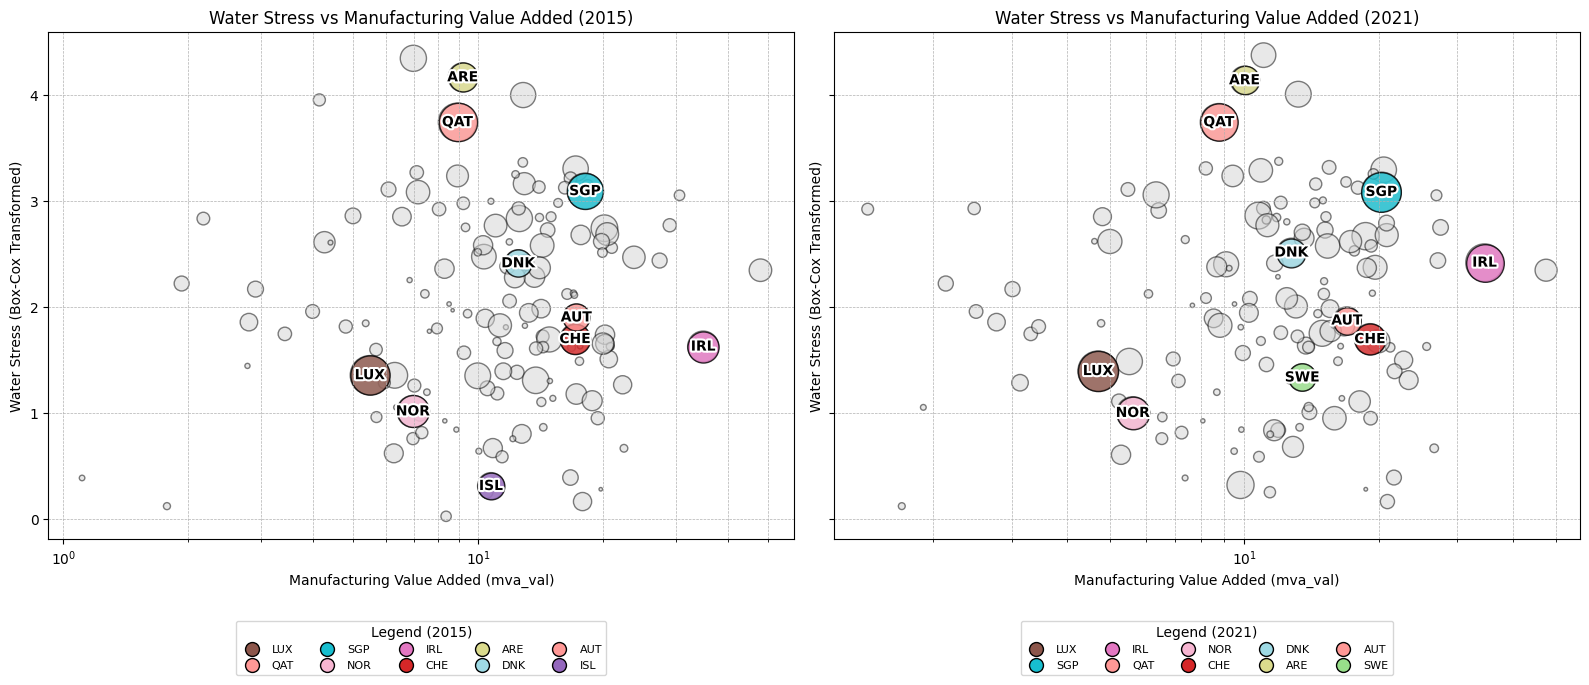

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import patheffects

# -----------------------
# 1) HELPER FUNCTIONS
# -----------------------
def is_gray(color, threshold=0.05):
    """Determines if a color tuple (R, G, B) is 'close' to gray."""
    r, g, b = color
    avg = (r + g + b) / 3
    diff_sum = abs(r - avg) + abs(g - avg) + abs(b - avg)
    return diff_sum < threshold

# -----------------------
# 2) PREPARE DATA
# -----------------------
year_2015 = 2015
last_year = FE_df["Year"].max()

df_2015 = FE_df[FE_df["Year"] == year_2015].copy()
df_last = FE_df[FE_df["Year"] == last_year].copy()

# -----------------------
# 3) CREATE NON-GRAY PALETTE
# -----------------------
countries = FE_df["Code"].unique()
num_countries = len(countries)

# Generate a large color palette to filter out grays
expanded_colors = sns.color_palette("tab20", num_countries * 2)
filtered_colors = [c for c in expanded_colors if not is_gray(c)]
filtered_colors = filtered_colors[:num_countries]

# Map each country to a distinct non-gray color
color_map = dict(zip(countries, filtered_colors))

# Adjust bubble scaling for GDP values
scaling_factor = df_2015["gdpy_val"].max() / 800

# -----------------------
# 4) PLOTTING FUNCTION
# -----------------------
def plot_scatter(df, year, ax, top_n=10):
    """Plots all points in light grey, highlights the top N largest bubbles, with improved label readability."""
    highlighted = pd.DataFrame()

    # Plot all points in light gray
    ax.scatter(
        df["mva_val"],
        df["val_water_stress_boxcox"],
        s=df["gdpy_val"] / scaling_factor,
        color="lightgrey",
        alpha=0.5,
        edgecolor="black"
    )
    
    # Highlight only the top N largest bubbles
    sub_highlight = df.sort_values("gdpy_val", ascending=False).head(top_n)
    highlighted = pd.concat([highlighted, sub_highlight])
    
    for _, row in sub_highlight.iterrows():
        ax.scatter(
            row["mva_val"],
            row["val_water_stress_boxcox"],
            s=row["gdpy_val"] / scaling_factor,
            color=color_map[row["Code"]],
            alpha=0.8,
            edgecolor="black"
        )
        # Improved label readability with a white outline
        ax.text(
            row["mva_val"],
            row["val_water_stress_boxcox"],
            row["Code"],
            fontsize=10,
            weight='bold',
            ha="center",
            va="center",
            color="black",
            path_effects=[plt.matplotlib.patheffects.withStroke(linewidth=3, foreground="white")]
        )

    ax.set_xscale("log")
    ax.set_xlabel("Manufacturing Value Added (mva_val)")
    ax.set_ylabel("Water Stress (Box-Cox Transformed)")
    ax.set_title(f"Water Stress vs Manufacturing Value Added ({year})")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    return highlighted

# -----------------------
# 5) MAKE THE SUBPLOTS
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

highlighted_2015 = plot_scatter(df_2015, year_2015, axes[0])
highlighted_last = plot_scatter(df_last, last_year, axes[1])

# -----------------------
# 6) ADDING LEGENDS
# -----------------------
def add_legend(ax, highlighted_df, title):
    """Creates a legend with only the highlighted country codes and colors."""
    legend_handles = []
    legend_labels = []
    
    for _, row in highlighted_df.iterrows():
        handle = plt.Line2D(
            [0], [0],
            marker='o', color='w',
            markerfacecolor=color_map[row["Code"]],
            markersize=10,
            markeredgecolor="black"
        )
        legend_handles.append(handle)
        legend_labels.append(row["Code"])

    ax.legend(legend_handles, legend_labels, title=title, loc="upper center",
              bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=8, frameon=True)

add_legend(axes[0], highlighted_2015, f"Legend ({year_2015})")
add_legend(axes[1], highlighted_last, f"Legend ({last_year})")

plt.tight_layout()
plt.show()




In [ ]:
import math

# Compute predictions from your fixed effects model (model_fe)
FE_df["predicted_stress"] = model_fe.predict(FE_df)

# Get sorted unique country codes from the "Code" column
countries = sorted(FE_df["Code"].unique())
num_countries = len(countries)

# Use a pleasing palette (e.g., "tab20") and assign a unique color to each country
colors = sns.color_palette("tab20", num_countries)
color_map = dict(zip(countries, colors))

# Set up a grid of subplots (here, 4 columns)
cols = 4  
rows = math.ceil(num_countries / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
axes = axes.flatten()

# Loop over each country, plot actual and predicted water stress values over time
for i, code in enumerate(countries):
    ax = axes[i]
    # Filter and sort data for the current country by Year
    country_data = FE_df[FE_df["Code"] == code].sort_values("Year")
    
    # Plot the actual water stress values (solid line with circle markers)
    ax.plot(country_data["Year"], country_data["val_water_stress_boxcox"], 
            label="Actual", color=color_map[code], linestyle='-', marker='o', linewidth=1.5)
    
    # Plot the predicted water stress values (dashed line with cross markers)
    ax.plot(country_data["Year"], country_data["predicted_stress"], 
            label="Predicted", color=color_map[code], linestyle='--', marker='x', linewidth=1.5)
    
    ax.set_title(code, fontsize=10)
    ax.set_xlabel("Year", fontsize=8)
    ax.set_ylabel("Water Stress (Box-Cox)", fontsize=8)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.grid(True, linestyle="--", linewidth=0.5)
    ax.legend(fontsize=8)

# Remove any unused subplots if the grid has extra axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


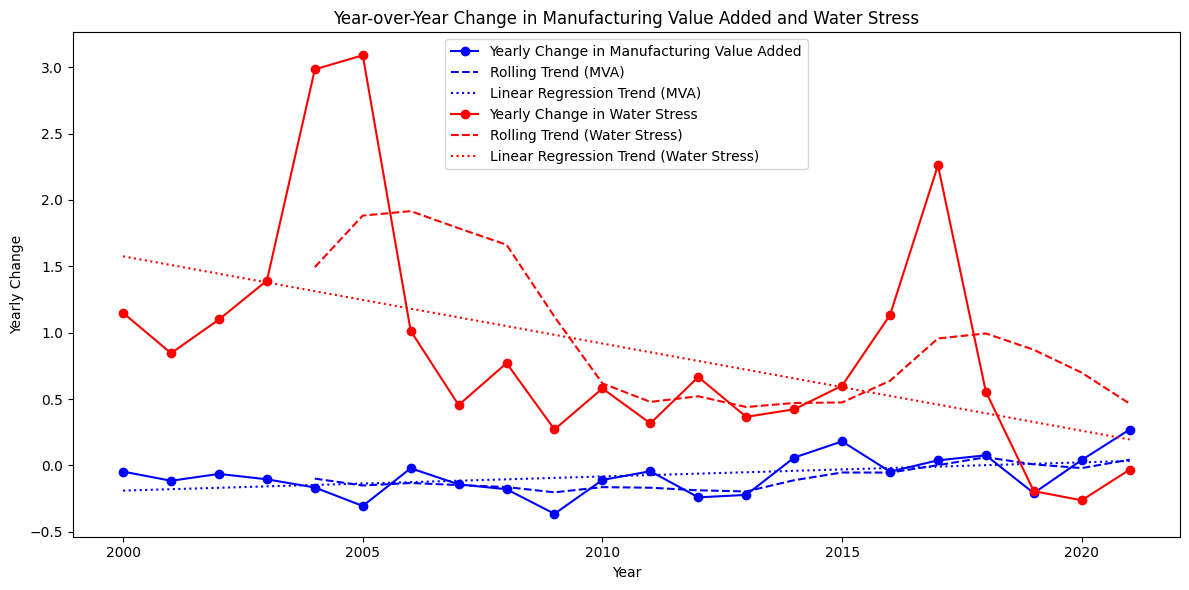

In [ ]:
# Calculate Year-over-Year (YoY) changes for Manufacturing Value Added and Water Stress
df_did['dmva_val'] = df_did.groupby('Code')['mva_val'].diff()
df_did['dwater_stress'] = df_did.groupby('Code')['val_water_stress'].diff()

# Group by Year and calculate the mean yearly change for each year
yearly_changes = df_did.groupby('Year')[['dmva_val', 'dwater_stress']].mean()

# --- Rolling Mean Trend (Smoothing) ---
rolling_window = 5  # Adjust the window size (e.g., 5 years)
yearly_changes['rolling_trend_mva'] = yearly_changes['dmva_val'].rolling(window=rolling_window).mean()
yearly_changes['rolling_trend_stress'] = yearly_changes['dwater_stress'].rolling(window=rolling_window).mean()

# --- Linear Regression Trend Line ---
# Drop NA values to avoid misalignment issues
yearly_changes = yearly_changes.dropna(subset=['dmva_val', 'dwater_stress'])

# Prepare the data for linear regression
X = yearly_changes.index.values.reshape(-1, 1)  # Reshape for linear regression
y_mva = yearly_changes['dmva_val']
y_stress = yearly_changes['dwater_stress']

# Perform linear regression for both variables
reg_mva = LinearRegression().fit(X, y_mva)
reg_stress = LinearRegression().fit(X, y_stress)

# Get the regression lines
yearly_changes['regression_trend_mva'] = reg_mva.predict(X)
yearly_changes['regression_trend_stress'] = reg_stress.predict(X)

# Plotting the changes and trends
plt.figure(figsize=(12, 6))

# Plot the yearly change in Manufacturing Value Added
plt.plot(yearly_changes.index, yearly_changes['dmva_val'], 
         label="Yearly Change in Manufacturing Value Added", color='blue', marker='o')
plt.plot(yearly_changes.index, yearly_changes['rolling_trend_mva'], 
         label="Rolling Trend (MVA)", color='blue', linestyle='--')
plt.plot(yearly_changes.index, yearly_changes['regression_trend_mva'], 
         label="Linear Regression Trend (MVA)", color='blue', linestyle=':')

# Plot the yearly change in Water Stress
plt.plot(yearly_changes.index, yearly_changes['dwater_stress'], 
         label="Yearly Change in Water Stress", color='red', marker='o')
plt.plot(yearly_changes.index, yearly_changes['rolling_trend_stress'], 
         label="Rolling Trend (Water Stress)", color='red', linestyle='--')
plt.plot(yearly_changes.index, yearly_changes['regression_trend_stress'], 
         label="Linear Regression Trend (Water Stress)", color='red', linestyle=':')

# Add labels, title, and legend
plt.xlabel("Year")
plt.ylabel("Yearly Change")
plt.title("Year-over-Year Change in Manufacturing Value Added and Water Stress")
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


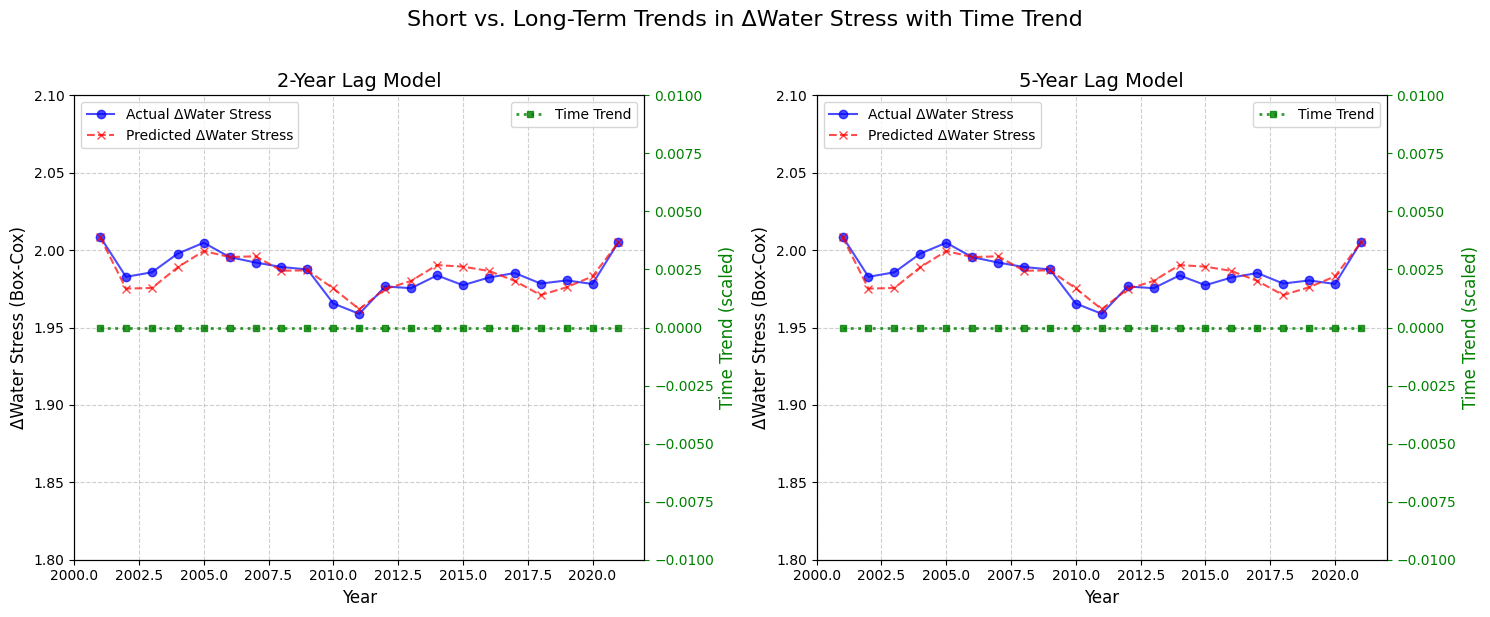

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set up the figure and subplots for the 2 models
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # 1 row, 2 columns
fig.suptitle("Short vs. Long-Term Trends in ΔWater Stress with Time Trend", fontsize=16, y=1.02)

# Function to plot trends for a given model with a secondary y-axis for the time trend
def plot_trends(ax, overall_trends, title, color_actual="blue", color_predicted="red", color_trend="green"):
    # Plot the actual water stress changes with larger markers
    ax.plot(overall_trends["Year"], overall_trends["actual_d_water_stress"], 
            label="Actual ΔWater Stress", color=color_actual, linestyle='-', marker='o', markersize=6, alpha=0.7)
    
    # Plot the predicted water stress changes with distinct dashed lines
    ax.plot(overall_trends["Year"], overall_trends["predicted_d_water_stress"], 
            label="Predicted ΔWater Stress", color=color_predicted, linestyle='--', marker='x', markersize=6, alpha=0.7)
    
    # Create a secondary y-axis for the time trend
    ax2 = ax.twinx()
    
    # Plot the time trend with amplified scaling on the secondary axis
    ax2.plot(overall_trends["Year"], overall_trends["time_trend_values"], 
             label="Time Trend", color=color_trend, linestyle=':', linewidth=2, alpha=0.8, marker='s', markersize=4)
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("ΔWater Stress (Box-Cox)", fontsize=12)
    ax.legend(loc="upper left", fontsize=10, frameon=True)
    ax.grid(True, linestyle="--", alpha=0.6)

    # Set y-axis limits for water stress
    ax.set_ylim(1.8, 2.1)

    # Set y-axis for the time trend with explicit scaling
    ax2.set_ylabel("Time Trend (scaled)", fontsize=12, color=color_trend)
    ax2.set_ylim(-0.01, 0.01)  # Force the time trend into a visible range
    ax2.tick_params(axis='y', colors=color_trend)
    ax2.legend(loc="upper right", fontsize=10, frameon=True)

# --- 2-Year Lag Model ---
# Compute the time trend and predictions for the 2-year lagged model
time_trend_coef_lag2 = model_2_lagged.params.get("time_trend", 0)
FE_df["time_trend_values_lag2"] = time_trend_coef_lag2 * FE_df["Year"]
FE_df["pred_d_water_stress_lag2"] = model_2_lagged.predict(FE_df)

# Aggregate trends for the 2-year lag model
overall_trends_lag2 = FE_df.groupby("Year").agg(
    actual_d_water_stress=("val_water_stress_boxcox", "mean"),
    predicted_d_water_stress=("pred_d_water_stress_lag2", "mean"),
    time_trend_values=("time_trend_values_lag2", "mean")
).reset_index()

# Plot the 2-year lag model
plot_trends(axes[0], overall_trends_lag2, "2-Year Lag Model")

# --- 5-Year Lag Model ---
# Compute the time trend and predictions for the 5-year lagged model
time_trend_coef_lag5 = model_5_lagged.params.get("time_trend", 0)
FE_df["time_trend_values_lag5"] = time_trend_coef_lag5 * FE_df["Year"]
FE_df["pred_d_water_stress_lag5"] = model_5_lagged.predict(FE_df)

# Aggregate trends for the 5-year lag model
overall_trends_lag5 = FE_df.groupby("Year").agg(
    actual_d_water_stress=("val_water_stress_boxcox", "mean"),
    predicted_d_water_stress=("pred_d_water_stress_lag5", "mean"),
    time_trend_values=("time_trend_values_lag5", "mean")
).reset_index()

# Plot the 5-year lag model
plot_trends(axes[1], overall_trends_lag5, "5-Year Lag Model")

# Adjust layout and display
plt.tight_layout()
plt.show()


In [ ]:
# Check the model parameters to verify the time trend naming
print("2-Year Lagged Model Parameters:")
print(model_2_lagged.params)

print("\n5-Year Lagged Model Parameters:")
print(model_5_lagged.params)

# Directly extract the correct time trend coefficient
time_trend_coef_lag2 = model_2_lagged.params["C(Year)[T.2020]"] if "C(Year)[T.2020]" in model_2_lagged.params else 0
time_trend_coef_lag5 = model_5_lagged.params["C(Year)[T.2020]"] if "C(Year)[T.2020]" in model_5_lagged.params else 0

print("\nExtracted Time Trend Coefficient (2-Year Lag):", time_trend_coef_lag2)
print("Extracted Time Trend Coefficient (5-Year Lag):", time_trend_coef_lag5)


2-Year Lagged Model Parameters:
Intercept               0.040611
mva_val                 0.000036
mva_val_lag             0.000196
val_water_stress_lag    0.999095
basic_water_services   -0.000443
Disaster_Count          0.000142
dtype: float64

5-Year Lagged Model Parameters:
Intercept               0.051931
mva_val                 0.000038
mva_val_lag             0.000214
val_water_stress_lag    0.999156
Disaster_Count          0.000042
basic_water_services   -0.000323
log_gdpy_val           -0.002301
dtype: float64

Extracted Time Trend Coefficient (2-Year Lag): 0
Extracted Time Trend Coefficient (5-Year Lag): 0


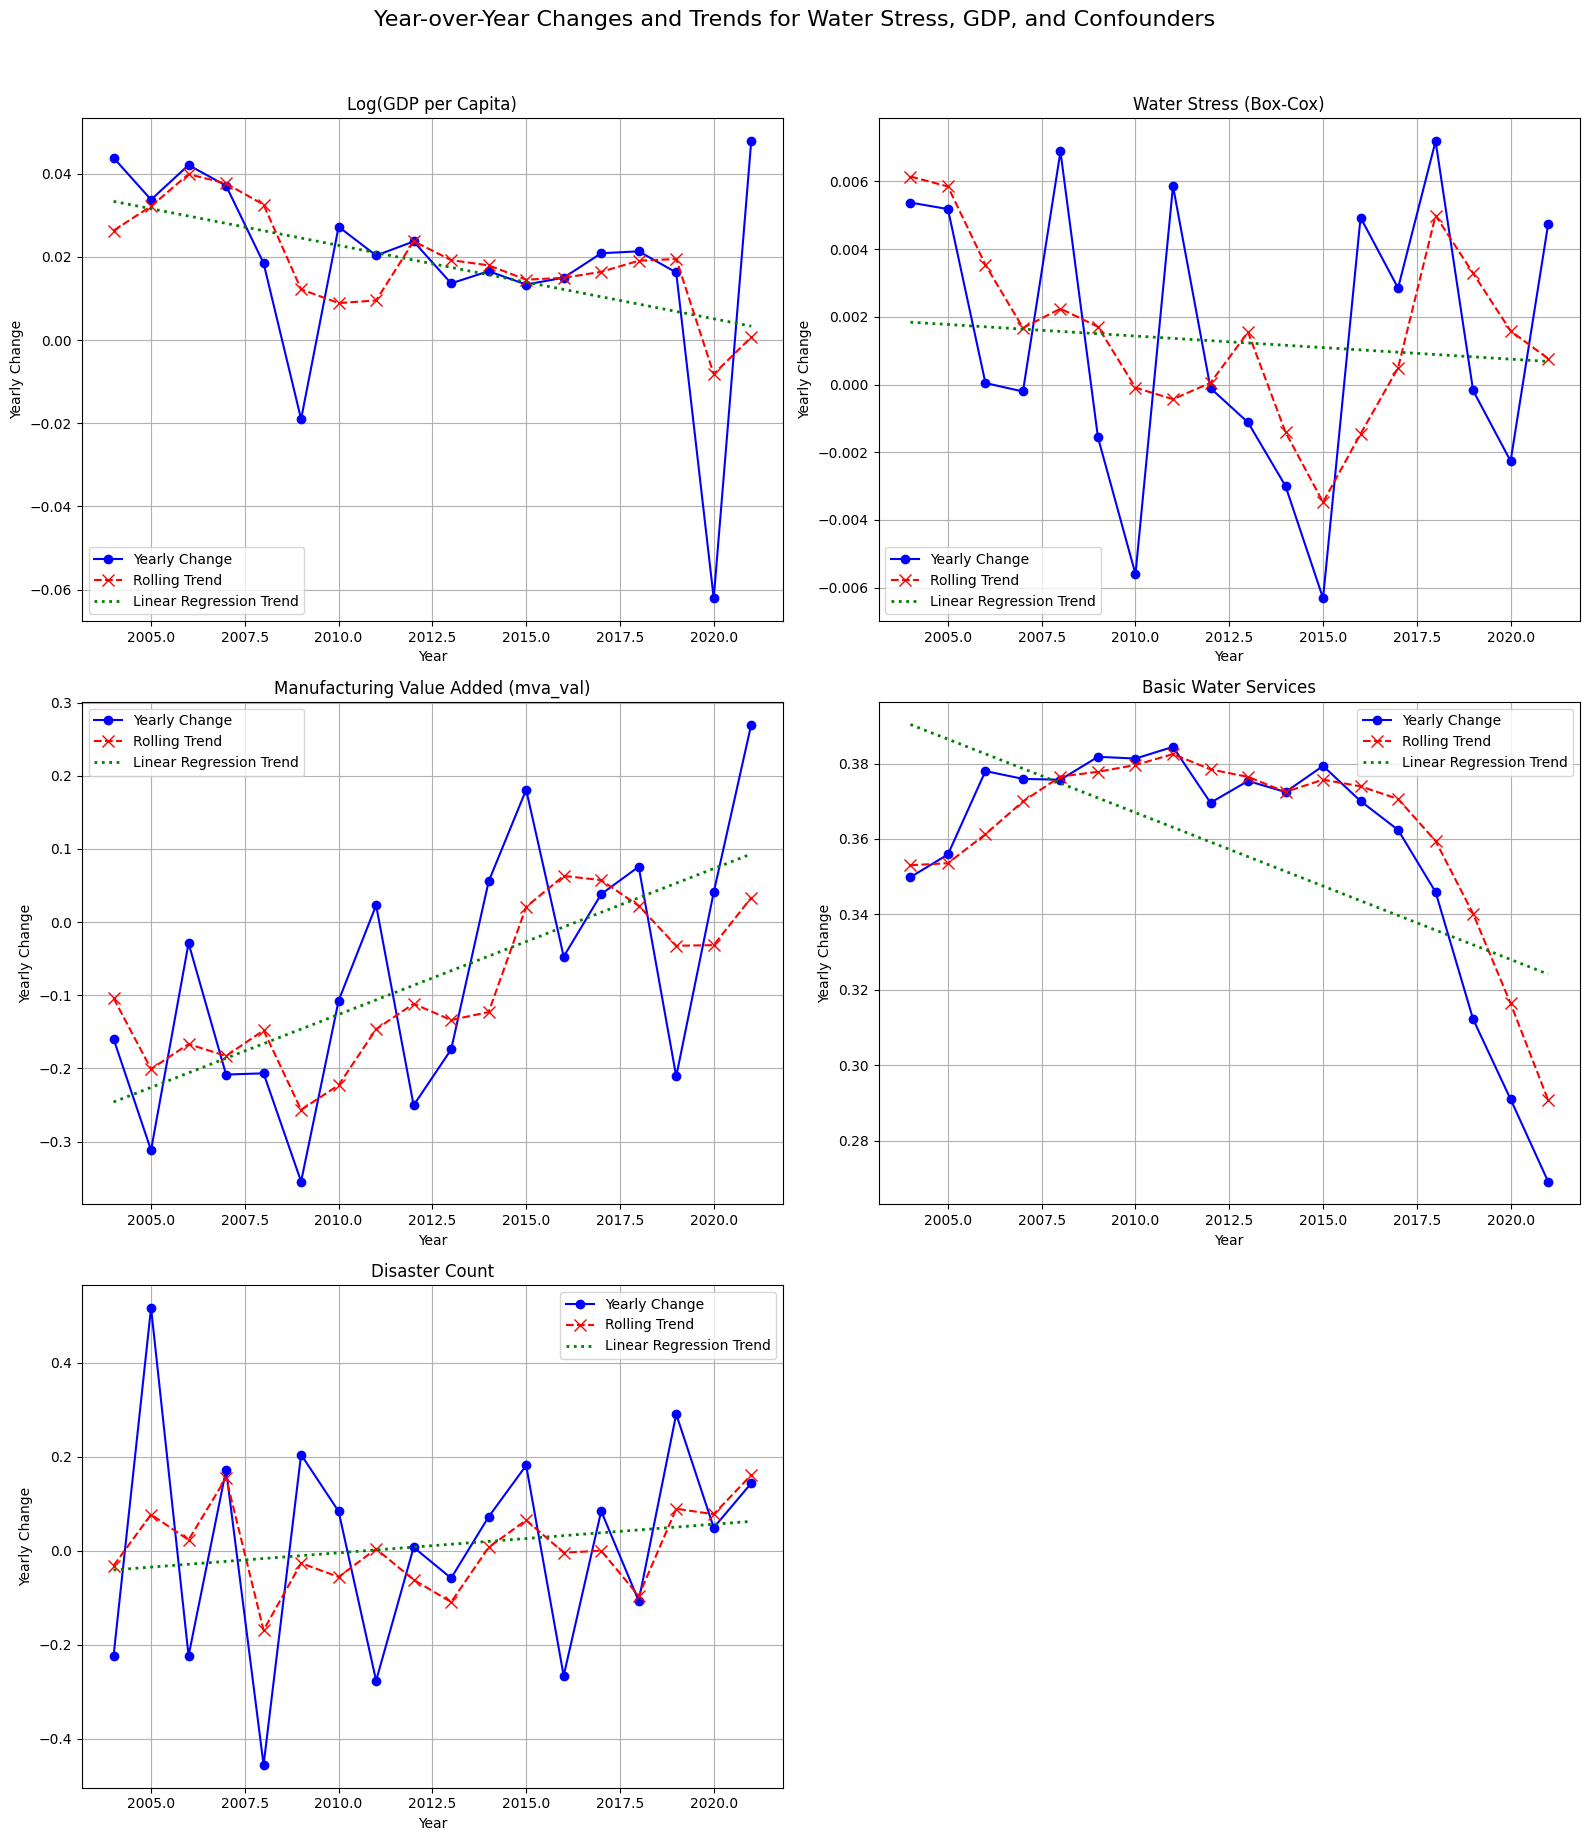

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- Calculate Year-over-Year (YoY) Changes ---
FE_df['dlog_gdpy'] = FE_df.groupby('Code')['log_gdpy_val'].diff()
FE_df['dval_water_stress'] = FE_df.groupby('Code')['val_water_stress_boxcox'].diff()
FE_df['dmva_val'] = FE_df.groupby('Code')['mva_val'].diff()
FE_df['dbasic_water_services'] = FE_df.groupby('Code')['basic_water_services'].diff()
FE_df['ddisaster_count'] = FE_df.groupby('Code')['Disaster_Count'].diff()

# --- Group by Year and Calculate Mean Yearly Change ---
yearly_changes = FE_df.groupby('Year')[['dlog_gdpy', 'dval_water_stress', 'dmva_val', 
                                        'dbasic_water_services', 'ddisaster_count']].mean()

# --- Rolling Mean Trend (Smoothing) ---
rolling_window = 3
yearly_changes['rolling_trend_dlog_gdpy'] = yearly_changes['dlog_gdpy'].rolling(window=rolling_window).mean()
yearly_changes['rolling_trend_dval_water_stress'] = yearly_changes['dval_water_stress'].rolling(window=rolling_window).mean()
yearly_changes['rolling_trend_dmva_val'] = yearly_changes['dmva_val'].rolling(window=rolling_window).mean()
yearly_changes['rolling_trend_dbasic_water_services'] = yearly_changes['dbasic_water_services'].rolling(window=rolling_window).mean()
yearly_changes['rolling_trend_ddisaster_count'] = yearly_changes['ddisaster_count'].rolling(window=rolling_window).mean()

# --- Linear Regression Trend Line ---
yearly_changes = yearly_changes.dropna()

X = yearly_changes.index.values.reshape(-1, 1)
for col in ['dlog_gdpy', 'dval_water_stress', 'dmva_val', 'dbasic_water_services', 'ddisaster_count']:
    model = LinearRegression().fit(X, yearly_changes[col])
    yearly_changes[f'regression_trend_{col}'] = model.predict(X)

# --- Plotting ---
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("Year-over-Year Changes and Trends for Water Stress, GDP, and Confounders", fontsize=16, y=1.02)

variables = [
    ('dlog_gdpy', 'Log(GDP per Capita)'),
    ('dval_water_stress', 'Water Stress (Box-Cox)'),
    ('dmva_val', 'Manufacturing Value Added (mva_val)'),
    ('dbasic_water_services', 'Basic Water Services'),
    ('ddisaster_count', 'Disaster Count')
]

# Define consistent colors
colors = {
    "Yearly Change": "blue",
    "Rolling Trend": "red",
    "Linear Regression Trend": "green"
}

axes = axes.flatten()

for ax, (var, title) in zip(axes, variables):
    ax.plot(yearly_changes.index, yearly_changes[var], 
            label="Yearly Change", color=colors["Yearly Change"], marker='o', linestyle='-')
    
    ax.plot(yearly_changes.index, yearly_changes[f'rolling_trend_{var}'], 
            label="Rolling Trend", color=colors["Rolling Trend"], linestyle='--', marker='x', markersize=8)
    
    ax.plot(yearly_changes.index, yearly_changes[f'regression_trend_{var}'], 
            label="Linear Regression Trend", color=colors["Linear Regression Trend"], linestyle=':', linewidth=2)
    
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("Yearly Change")
    ax.legend()
    ax.grid(True)

# Remove the empty subplot (if any)
if len(variables) < len(axes):
    fig.delaxes(axes[len(variables)])

plt.tight_layout()
plt.show()


# SUGGESTIONS: 

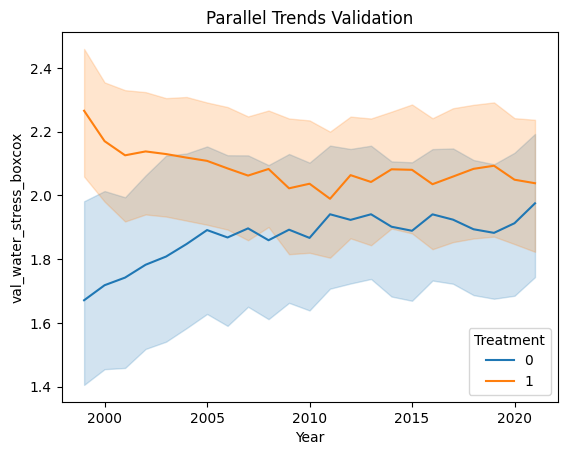

In [ ]:

# Parallel Trends Validation
sns.lineplot(data=df_did, x='Year', y='val_water_stress_boxcox', hue='Treatment')
plt.title('Parallel Trends Validation')
plt.show()



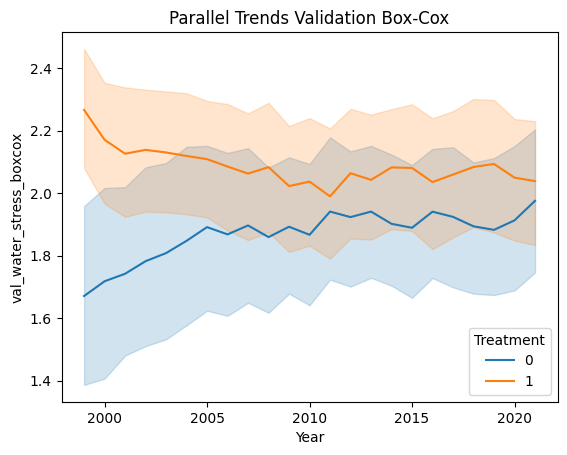

In [ ]:

# Parallel Trends Validation
sns.lineplot(data=df_did, x='Year', y='val_water_stress_boxcox', hue='Treatment')
plt.title('Parallel Trends Validation Box-Cox')
plt.show()

